In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
filename = f"series_equidistantes_interp_delta_mult.pkl"

with open(filename, "rb") as f:
    data = pickle.load(f)

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

WINDOWS = {
    "9798_6253": (9798, 6253),
    "6182_3842": (6253, 3842),
    "3771_-57": (3842, -57)
}

#quitar últimas dos columnas de data
data = data.iloc[:, :-2]

In [8]:
data_norm = data.copy()

for col in data.columns[1:]:
    media = data[col].mean()
    std = data[col].std()
    data_norm[col] = (data[col] - media) / std

ventanas = {
    name: extraer_ventana(data_norm, *lims)
    for name, lims in WINDOWS.items()
}

dispersion = {}

for name, df_w in ventanas.items():
    stds = df_w.iloc[:, 1:].std()  # por especie
    dispersion[name] = stds.mean()  # promedio entre especies


cv_por_ventana = {}

for name, df_w in ventanas.items():
    cv = df_w.iloc[:, 1:].std() / df_w.iloc[:, 1:].mean()
    cv_por_ventana[name] = cv.mean()

from scipy.stats import entropy

diversidad = {}

for name, df_w in ventanas.items():
    entropias = []
    
    for _, row in df_w.iterrows():
        p = row.iloc[1:]
        p = p / p.sum()
        entropias.append(entropy(p))
    
    diversidad[name] = np.mean(entropias)

<Axes: xlabel='ventana', ylabel='valor'>

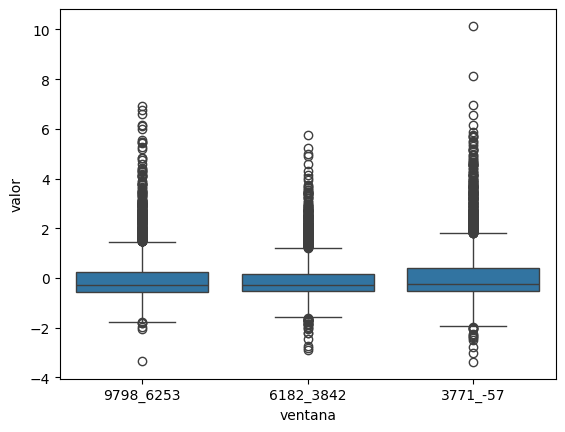

In [9]:
import seaborn as sns

df_plot = []

for name, df_w in ventanas.items():
    for col in df_w.columns[1:]:
        for val in df_w[col]:
            df_plot.append({"ventana": name, "valor": val})

df_plot = pd.DataFrame(df_plot)

sns.boxplot(x="ventana", y="valor", data=df_plot)

In [25]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

resultados_metricas = []

for name, lims in WINDOWS.items():
    df_w = extraer_ventana(data, *lims)
    especies = df_w.columns[1:]

    # --- Coeficiente de variación (por especie → media)
    cv = (df_w[especies].std() / df_w[especies].mean()).mean()

    # --- Diversidad (Shannon)
    entropias = []

    for _, row in df_w.iterrows():
        p = row[especies]
        p = p / p.sum()
        
        p = p[p > 0]  # 🔑 quitar ceros
        
        entropias.append(entropy(p))
    diversidad = np.mean(entropias)

    # --- Media de abundancia (opcional)
    media = df_w[especies].mean().mean()

    resultados_metricas.append({
        "ventana": name,
        "CV": cv,
        "diversidad": diversidad,
        "media": media
    })

df_metricas = pd.DataFrame(resultados_metricas)

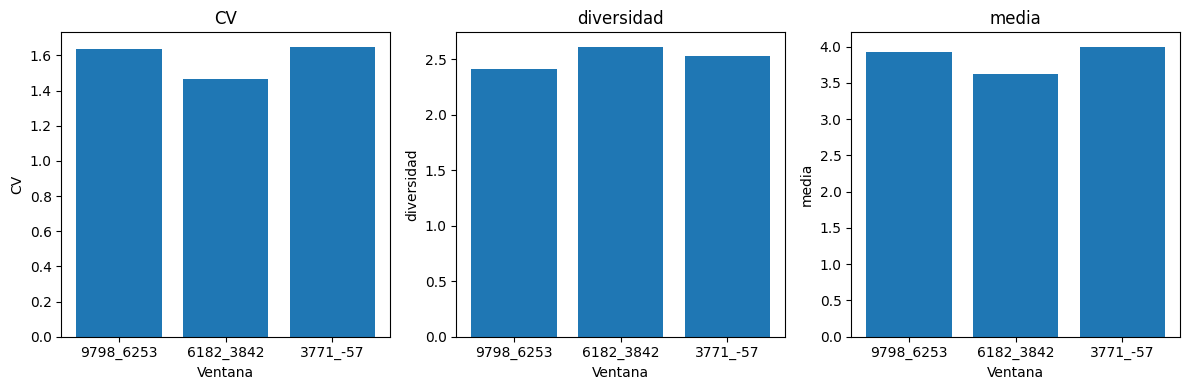

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for i, m in enumerate(["CV", "diversidad", "media"]):
    axs[i].bar(df_metricas["ventana"], df_metricas[m])
    axs[i].set_title(m)
    axs[i].set_xlabel("Ventana")
    axs[i].set_ylabel(m)

plt.tight_layout()
plt.show()

In [30]:
import pickle
import numpy as np
import networkx as nx

windows_names = ["w1", "w2", "w3"]
tipos = ["wio", "0.5"]  # opcional si quieres comparar

resultados = {}

for w in windows_names:
    resultados[w] = {}
    
    for tipo in tipos:
        filename = f"results_{w}_{tipo}.pkl"
        
        with open(filename, "rb") as f:
            data = pickle.load(f)
        
        especies = data["especies"]
        matriz_sig = np.array(data["matriz_significancia"])
        
        # --- construir grafo dirigido
        G = nx.DiGraph()
        G.add_nodes_from(especies)
        
        for i in range(len(especies)):
            for j in range(len(especies)):
                if matriz_sig[i, j] == 1:
                    G.add_edge(especies[i], especies[j])
        
        # --- convertir a no dirigido
        G_und = G.to_undirected()
        
        # --- centralidad de subgrafo
        centralidad = nx.subgraph_centrality(G_und)
        
        # --- ordenar especies por centralidad
        valores = np.array(list(centralidad.values()))
        valores_sorted = np.sort(valores)[::-1]
        
        # --- top 10%
        n_top = max(1, int(0.1 * len(valores_sorted)))
        top_sum = valores_sorted[:n_top].sum()
        total_sum = valores.sum()
        
        porcentaje = 100 * top_sum / total_sum
        
        resultados[w][tipo] = porcentaje

Text(0.5, 1.0, 'Comparación de centralidad entre tipos')

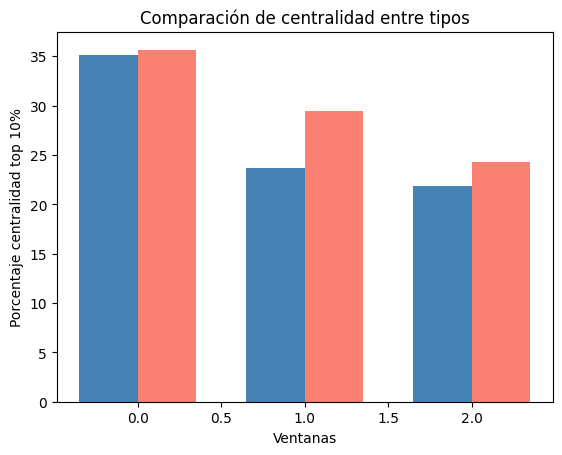

In [31]:
# plot resultados

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x = np.arange(len(windows_names))
width = 0.35
colors = ["steelblue", "salmon"]
# Barras
ax.bar(x - width/2, [resultados[w]["wio"] for w in windows_names], width, label="0.9", color=colors[0])
ax.bar(x + width/2, [resultados[w]["0.5"] for w in windows_names], width, label="0.5", color=colors[1])
ax.set_xlabel("Ventanas")
ax.set_ylabel("Porcentaje centralidad top 10%")
ax.set_title("Comparación de centralidad entre tipos")

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.0005

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6253, 3842),
    #"3771_-57": (3842, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult_neg_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"bm_{window_name}_pc.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

ModuleNotFoundError: No module named 'numpy._core.numeric'